# cGAN Training

### Goal - To build and train our **conditional GAN (cGAN)** - a generative model that learsn to create **synthetic handwriting images** conditioned on digit labels

## Plan 

1. Understand the architecture of a **conditional Gan (cGAN)**
2. Implement **Generator** and **discriminator** in pytorch
3. Train model with adversarial objectives
4. Visualise class-conditional handwriting samples

## Recap (cGAN)

A **Generative Adversarial Network (GAN)** consists of:
- A **Generator (G)** that creates fake samples from random noise.
- A **Discriminator (D)** that tries to tell real from fake.

In a **Conditional GAN**, both G and D receive an **additional input**: a *class label*.  
This allows the model to generate specific digits or characters on demand.

In [2]:
# import core libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import numpy as np

import os, sys

from data_utils.dataloader import get_mnist_loaders
from model.cgan import Generator, Discriminator
from utils.visualize import show_batch
from utils.checkpoint import save_checkpoint

device = (
    "cuda" if torch.cuda.is_available() 
    else "mps" if torch.backends.mps.is_available() 
    else "cpu"
)
print(f" Running on device: {device}")

 Running on device: cuda


### Define Model Hyperparameters 


We’ll use a low-dimensional latent space (`z_dim = 100`),  
and condition the model on **10 digit classes (0–9)**.

GANs are notoriously sensitive to hyperparameters —  
we’ll start simple and iterate.

In [3]:
# hyperparameters 
z_dim = 100
num_classes = 10
img_shape = (1, 28, 28)
batch_size = 128
lr = 0.0002
epochs = 50

In [5]:
#ToDO: extract the data 
#Tip: Use the `get_mnist_loader` function in dataloader.py
train_loader, test_loader = get_mnist_loaders(batch_size=batch_size)

Before we dive into training, let's define both our **Generator** and **Discriminator**.

Each will use the label embedding trick — where we turn the class label (e.g., “3”) into a learnable vector that can be concatenated with the noise or image input.

Our models are intentionally **lightweight** to make training on CPU/MPS feasible.  We’ll focus on the learning process and class conditioning rather than pixel-perfect realism.

In [6]:
##ToDo: initialize models and optimizers

# Initialize Generator and Discriminator
generator = Generator(
    z_dim=z_dim,
    num_classes=num_classes,
    img_shape=img_shape
).to(device)

discriminator = Discriminator(
    num_classes=num_classes,
    img_shape=img_shape
).to(device)

# Define binary cross-entropy loss
criterion = nn.BCELoss()

# Initialize optimizers
optimizer_G = optim.Adam(
    generator.parameters(),
    lr=lr,
    betas=(0.5, 0.999)
)

optimizer_D = optim.Adam(
    discriminator.parameters(),
    lr=lr,
    betas=(0.5, 0.999)
)

print("Generator and Discriminator initialized successfully.")

Generator and Discriminator initialized successfully.


## Training Strategy

We’ll alternate between training the **Discriminator (D)** and **Generator (G)**.

1. **Train D:**  
   - Use real images labeled as 1  
   - Use fake images (from G) labeled as 0  

2. **Train G:**  
   - Generate fake images  
   - Fool D into predicting them as 1  

This adversarial game continues until G generates *realistic*, class-conditioned digits.

In [8]:
#ToDo:    
# 1. Implement training loop 
# 2. Save D & G every 10 epochs

# Create directory for model checkpoints
os.makedirs("checkpoints", exist_ok=True)

generator.train()
discriminator.train()

for epoch in range(epochs):
    for batch_idx, (real_images, real_labels) in enumerate(train_loader):
        real_images = real_images.to(device)
        real_labels = real_labels.to(device)

        current_batch_size = real_images.size(0)

        # Create real and fake target labels
        valid = torch.ones(current_batch_size, 1, device=device)
        fake = torch.zeros(current_batch_size, 1, device=device)

        # ---------------------
        # Train Discriminator
        # ---------------------
        optimizer_D.zero_grad()

        # Calculate loss for real images
        real_predictions = discriminator(real_images, real_labels)
        real_loss = criterion(real_predictions, valid)

        # Generate fake images
        noise = torch.randn(current_batch_size, z_dim, device=device)
        generated_labels = torch.randint(
            0,
            num_classes,
            (current_batch_size,),
            device=device
        )
        generated_images = generator(noise, generated_labels)

        # Calculate loss for fake images
        fake_predictions = discriminator(
            generated_images.detach(),
            generated_labels
        )
        fake_loss = criterion(fake_predictions, fake)

        # Combine real and fake discriminator losses
        d_loss = (real_loss + fake_loss) / 2

        d_loss.backward()
        optimizer_D.step()

        # -----------------
        # Train Generator
        # -----------------
        optimizer_G.zero_grad()

        # Train the Generator to fool the Discriminator
        generated_predictions = discriminator(
            generated_images,
            generated_labels
        )
        g_loss = criterion(generated_predictions, valid)

        g_loss.backward()
        optimizer_G.step()

    print(
        f"[Epoch {epoch + 1}/{epochs}] "
        f"D loss: {d_loss.item():.4f} | "
        f"G loss: {g_loss.item():.4f}"
    )

    # Save Generator and Discriminator every 10 epochs
    if (epoch + 1) % 10 == 0:
        torch.save(
            generator.state_dict(),
            f"checkpoints/generator_epoch_{epoch + 1}.pt"
        )
        torch.save(
            discriminator.state_dict(),
            f"checkpoints/discriminator_epoch_{epoch + 1}.pt"
        )

        print(f"Saved checkpoints at epoch {epoch + 1}")


[Epoch 1/50] D loss: 0.5388 | G loss: 1.8160
[Epoch 2/50] D loss: 0.5578 | G loss: 2.1042
[Epoch 3/50] D loss: 0.6335 | G loss: 2.3898
[Epoch 4/50] D loss: 0.4452 | G loss: 1.5867
[Epoch 5/50] D loss: 0.4292 | G loss: 1.5642
[Epoch 6/50] D loss: 0.4988 | G loss: 1.1395
[Epoch 7/50] D loss: 0.4474 | G loss: 1.4895
[Epoch 8/50] D loss: 0.4510 | G loss: 1.1789
[Epoch 9/50] D loss: 0.5217 | G loss: 2.4851
[Epoch 10/50] D loss: 0.4889 | G loss: 1.5432
Saved checkpoints at epoch 10
[Epoch 11/50] D loss: 0.5012 | G loss: 1.2888
[Epoch 12/50] D loss: 0.6374 | G loss: 1.6410
[Epoch 13/50] D loss: 0.5825 | G loss: 0.6033
[Epoch 14/50] D loss: 0.4965 | G loss: 1.3699
[Epoch 15/50] D loss: 0.5634 | G loss: 1.3632
[Epoch 16/50] D loss: 0.5735 | G loss: 1.0331
[Epoch 17/50] D loss: 0.5540 | G loss: 0.8919
[Epoch 18/50] D loss: 0.5698 | G loss: 0.7672
[Epoch 19/50] D loss: 0.6054 | G loss: 0.7441
[Epoch 20/50] D loss: 0.6612 | G loss: 0.6027
Saved checkpoints at epoch 20
[Epoch 21/50] D loss: 0.5958 

In [11]:
# ToDo: Save Final Model

# Create checkpoint directory if it does not exist
os.makedirs("../checkpoints", exist_ok=True)

# Save final Generator model
torch.save(
    generator.state_dict(),
    "../checkpoints/cgan_generator_epochfinal.pt"
)

# Save final Discriminator model
torch.save(
    discriminator.state_dict(),
    "../checkpoints/cgan_discriminator_epochfinal.pt"
)

print("Final Generator and Discriminator models saved.")

Final Generator and Discriminator models saved.


### Note
Training GANs can be unstable.  
If losses oscillate, that’s expected — D and G are in constant competition.

Let’s visualize a few generated samples at the end of training to check if conditioning worked.

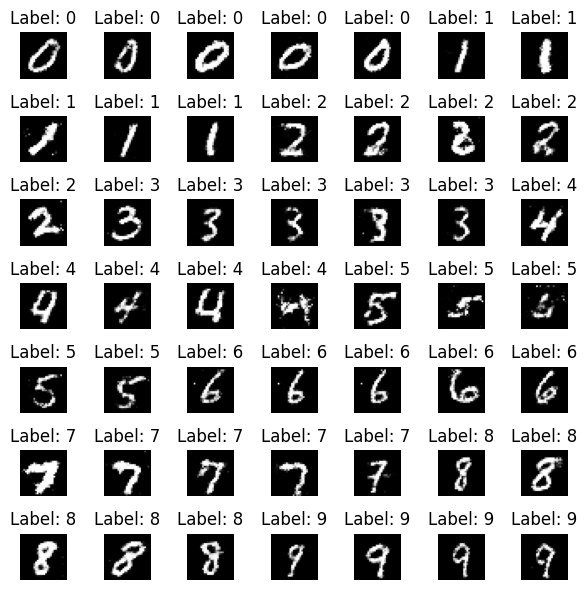

In [13]:
### Generate and visualize samples
def generate_samples(generator, n_classes=10, n_per_class=5):
    generator.eval()
    with torch.no_grad():
        z = torch.randn(n_classes * n_per_class, z_dim).to(device)
        labels = torch.tensor([i for i in range(n_classes) for _ in range(n_per_class)]).to(device)
        gen_imgs = generator(z, labels)
    generator.train()
    return gen_imgs, labels

gen_imgs, gen_labels = generate_samples(generator)
show_batch(gen_imgs.cpu(), gen_labels.cpu(), n=50)

We can now see grids of digits 0–9, each set showing several synthetic examples.  
Each class label corresponds to the digit the Generator was conditioned on.

Even if the images look a bit fuzzy, the model has learned the *concept* of conditioning —  
the generator “knows” which class to produce.